**Homework 19**

We begin as in Homework 18 by importing a set of face images:

In [122]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
faces=lfw_people.images

To assist with model building, it helps to clip the dimesnions of each image to numbers easily divisible by 2, and add a channel:

In [123]:
faces=faces[:,:48,:36] #clip each image to 48 x 36
faces=faces.reshape((1288,48,36,1)) #add a channel

The purpose of this assignment is to build a neural network to remove noise from images. You'll test your network on an image of George W. Bush:

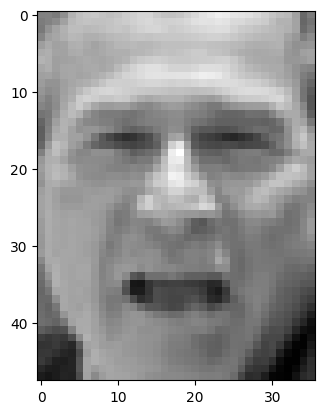

In [124]:
bush=faces[10]
plt.imshow(bush,cmap='gray')

Your goal will be to restore this image from one in which noise has been introduced:

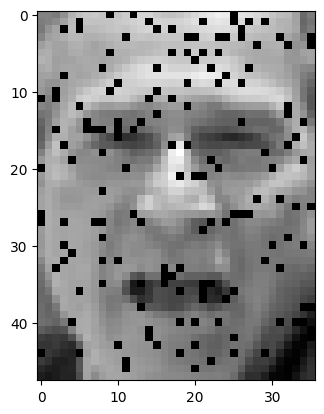

In [125]:
noisyface=(np.random.choice([0]+9*[1],48*36).reshape(48,36,1))*bush
plt.imshow(noisyface,cmap='gray')

We load the necessary model building imports from PyTorch.

In [126]:
import torch
import torch.nn as nn
from torch.optim import Adam

The first step is to convert our data to the correct type:

In [ ]:
faces=torch.tensor(faces).float().reshape(-1,1,48,36)

Now, build encoder, decoder, and autoencoder models. I've started this for you with a dropout layer in the encoder, which turns some pixels "off". This simulates noise in the image during training. During inference (i.e. when you use the trained model to remove noise form an image) don't forget to call model.eval() to turn off the Dropout layer. When we train this we'll use the same image for both feature and target, producing a model that takes in noisy images and produces "clean" ones.

Each image in the `faces` dataset is already normalized so the pixel values are between 0 and 1. Make sure the final layer of your decoder outputs only numbers between 0 and 1 (hint: what function did we learn in class that has outputs betwen 0 and 1?)

In [127]:
encoder=nn.Sequential(
    nn.Dropout(0.1),
    nn.Conv2d(1,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2)
)

decoder=nn.Sequential(
    nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
    nn.ReLU(),
    nn.ConvTranspose2d(32,1,3,stride=2,padding=1,output_padding=1),
    nn.Sigmoid()
)

autoencoder=nn.Sequential(encoder,decoder)

Define an Adam optimizer for this model with an initial learning rate of 0.001.

In [131]:
optimizer=Adam(autoencoder.parameters(),lr=0.001)

Define a training loop to fit your model. Periodically report your loss.

In [132]:
autoencoder.train()

n_epochs=40
N = faces.shape[0]  # total number of observations in training data
batch_size=32

for epoch in range(n_epochs):
  # Shuffle the indices
  indices = torch.randperm(N)

  # Create mini-batches
  for i in range(0, N, batch_size):
    batch_indices = indices[i:i+batch_size]
    batch_X = faces[batch_indices]

    optimizer.zero_grad()
    MSE=nn.MSELoss()(autoencoder(batch_X),batch_X)
    MSE.backward()
    optimizer.step()

  if epoch%2==0:
    print(f"epoch: {epoch}, loss: {MSE}")

epoch: 0, loss: 0.007305983453989029
epoch: 2, loss: 0.00454609002918005
epoch: 4, loss: 0.003251132322475314
epoch: 6, loss: 0.0028065561782568693
epoch: 8, loss: 0.002640210324898362
epoch: 10, loss: 0.0026951853651553392
epoch: 12, loss: 0.0026928784791380167
epoch: 14, loss: 0.002183448988944292
epoch: 16, loss: 0.002588002709671855
epoch: 18, loss: 0.002162813674658537
epoch: 20, loss: 0.0017391979927197099
epoch: 22, loss: 0.002065173350274563
epoch: 24, loss: 0.001875441987067461
epoch: 26, loss: 0.001723092165775597
epoch: 28, loss: 0.0020567059982568026
epoch: 30, loss: 0.0019123959355056286
epoch: 32, loss: 0.0016711748903617263
epoch: 34, loss: 0.0017483823467046022
epoch: 36, loss: 0.0017210862133651972
epoch: 38, loss: 0.0016612589824944735


If your model works correctly, this code should remove the noise in the noisyface image:

In [133]:
noisyface=torch.tensor(noisyface).float().reshape(1,1,48,36)

autoencoder.eval()
denoisedface=autoencoder(noisyface)

Let's look at it! You're image should be slightly blurrier than the original image, but all the black pixels should be restored.

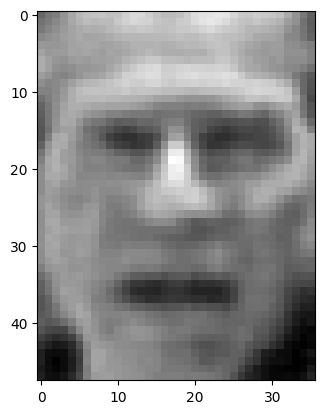

In [135]:
plt.imshow(denoisedface.detach().numpy().reshape(48,36),cmap='gray')

Take a screen shot of your denoised image, and upload that to gradescope. (You'll have to upload as a pdf. Contact me for help with file conversion, if you need it.)